In [1]:
# Ran with predictors_simple kernel
# Python 3.10.8

import numpy as np # 1.26.4
import pandas as pd # 2.2.3
import tensorflow as tf # 2.10.0
import matplotlib # 3.10.3
import torch # 2.0.0

matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['font.sans-serif'] = 'Arial'
from matplotlib import pyplot as plt

from joblib import load
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.metrics import auc
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.gridspec as gridspec
import seaborn as sns
import re

import os

os.chdir("/Users/claireleblanc/Documents/grad_school/staller_lab/NN_interpretability_for_AD_prediction/Model")
from ADModel_three_state import ADModel_three_state_abund
from ADModel_two_state import ADModel_two_state_abund
from Data import DataReader, SplitData, FastTensorDataLoader, one_hot_encode


os.chdir("/Users/claireleblanc/Documents/tools_software/adhunter")
from actpred.models import ActCNNSystem

# Set Numpy to display floats with 3 decimal places
np.set_printoptions(formatter={'float': lambda x: "{0:0.3f}".format(x)})

os.chdir("/Users/claireleblanc/Documents/grad_school/staller_lab/NN_interpretability_for_AD_prediction")

In [2]:
# Parameters to make figures work better with illustrator 
import matplotlib 
# For higher resoltion figures
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rcParams["font.family"] = "Helvetica" #somethings this one doesnt work
plt.rcParams['pdf.fonttype'] = 42

In [20]:
# These are the data files used in trainning
val_seqs = pd.read_csv("Data/prion_dms/prion_data_wrangled_validation.csv")
train_seqs = pd.read_csv("Data/prion_dms/prion_data_wrangled_training.csv")
test_seqs = pd.read_csv("Data/prion_dms/prion_data_wrangled_test.csv")


In [4]:
# For two state model:
# This is an attempt to choose the "best" model in an unbiased way
# Specifically, it tries to choose a model that has both a high pearson and a high spearman correlation
# It does this by choosing the model with the highest combined spearman and pearson rank

two_model_results = pd.read_csv("results/Faure_results_two_state_test_leakyReLU.csv")

two_model_results = two_model_results.sort_values("pearson_act_val", ascending=False)
two_model_results = two_model_results.reset_index()
two_model_results["r1"] = two_model_results.index

two_model_results = two_model_results.sort_values("spearman_act_val", ascending=False)
two_model_results = two_model_results.reset_index()
two_model_results["r2"] = two_model_results.index
two_model_results = two_model_results.drop(columns="level_0")

two_model_results = two_model_results.sort_values("pearson_abund_val", ascending=False)
two_model_results = two_model_results.reset_index()
two_model_results["r3"] = two_model_results.index
two_model_results = two_model_results.drop(columns="level_0")

two_model_results = two_model_results.sort_values("spearman_abund_val", ascending=False)
two_model_results = two_model_results.reset_index()
two_model_results["r4"] = two_model_results.index
two_model_results = two_model_results.drop(columns="level_0")


two_model_results["max_rank"] = two_model_results[["r1","r2","r3","r4"]].max(axis=1)            # min–max rule
two_model_results["sum_rank"] = two_model_results["r1"] + two_model_results["r2"] + two_model_results["r3"] + two_model_results["r4"]                  # Borda

In [5]:
two_model_results.sort_values("sum_rank") #.loc[0, 'model_name']

,index,model_name,model_type,kernel_size,activity_fun,negative_pen,weight_pen,hill_value,spearman_abund_test,spearman_act_test,...,K2_negative,abund_negative,relu,total_params,r1,r2,r3,r4,max_rank,sum_rank
1,1,../../model_data/Faure_two_state_abundmodel_b1...,two_state_abund,56,Hill,0.1,0.5,1,0.850759,0.813840,...,NaN,False,False,2248,5,5,0,1,5,11
5,7,../../model_data/Faure_two_state_abundmodel_b1...,two_state_abund,56,Hill,0.1,0.5,1,-0.704839,0.882529,...,NaN,False,False,2248,1,1,5,5,5,12
0,4,../../model_data/Faure_two_state_abundmodel_b1...,two_state_abund,56,Hill,0.1,0.5,1,0.848147,0.583014,...,NaN,False,False,2248,6,7,1,0,7,14
3,9,../../model_data/Faure_two_state_abundmodel_b1...,two_state_abund,56,Hill,0.1,0.5,1,0.836007,0.834654,...,NaN,False,False,2248,4,4,3,3,4,14
8,6,../../model_data/Faure_two_state_abundmodel_b1...,two_state_abund,56,Hill,0.1,0.5,1,-0.742842,0.882686,...,NaN,False,False,2248,0,0,8,8,8,16
2,5,../../model_data/Faure_two_state_abundmodel_b1...,two_state_abund,56,Hill,0.1,0.5,1,0.837026,0.590278,...,NaN,False,False,2248,7,6,2,2,7,17
6,8,../../model_data/Faure_two_state_abundmodel_b1...,two_state_abund,56,Hill,0.1,0.5,1,-0.715227,0.877290,...,NaN,False,False,2248,3,3,6,6,6,18
7,2,../../model_data/Faure_two_state_abundmodel_b1...,two_state_abund,56,Hill,0.1,0.5,1,-0.733419,0.880529,...,NaN,False,False,2248,2,2,7,7,7,18
4,0,../../model_data/Faure_two_state_abundmodel_b1...,two_state_abund,56,Hill,0.1,0.5,1,0.447000,0.259360,...,NaN,False,False,2248,8,8,4,4,8,24
9,3,../../model_data/Faure_two_state_abundmodel_b1...,two_state_abund,56,Hill,0.1,0.5,1,-0.754285,-0.581185,...,NaN,False,False,2248,9,9,9,9,9,36


In [6]:
# For three state model:
# This is an attempt to choose the "best" model in an unbiased way
# Specifically, it tries to choose a model that has both a high pearson and a high spearman correlation
# It does this by choosing the model with the highest combined spearman and pearson rank

three_model_results = pd.read_csv("results/PADI_results_three_state_abund_test.csv")

three_model_results = three_model_results.sort_values("pearson_act_val", ascending=False)
three_model_results = three_model_results.reset_index()
three_model_results["r1"] = three_model_results.index

three_model_results = three_model_results.sort_values("spearman_act_val", ascending=False)
three_model_results = three_model_results.reset_index()
three_model_results["r2"] = three_model_results.index
three_model_results = three_model_results.drop(columns="level_0")


three_model_results["max_rank"] = three_model_results[["r1","r2"]].max(axis=1)            # min–max rule
three_model_results["sum_rank"] = three_model_results["r1"] + three_model_results["r2"]                  # Borda

three_model_results.sort_values(["sum_rank"])

,index,model_name,model_type,kernel_size,activity_fun,negative_pen,weight_pen,hill_value,spearman_abund_test,spearman_act_test,...,pearson_act_train,K1_negative,K2_negative,abund_negative,relu,total_params,r1,r2,max_rank,sum_rank
4,142,../../model_data/PADI_three_state_abundmodel_b...,three_state_abund,30,Hill,0.1,0.5,1,0.342153,0.469402,...,0.530901,True,False,False,False,2037,1,4,4,5
10,202,../../model_data/PADI_three_state_abundmodel_b...,three_state_abund,30,Hill,0.1,0.5,1,0.321955,0.486019,...,0.528228,False,False,False,False,1657,2,10,10,12
6,238,../../model_data/PADI_three_state_abundmodel_b...,three_state_abund,30,Hill,0.1,0.5,1,0.335474,0.479760,...,0.522736,False,False,False,False,1657,14,6,14,20
21,172,../../model_data/PADI_three_state_abundmodel_b...,three_state_abund,30,Hill,0.1,0.5,1,0.337749,0.469309,...,0.542804,True,False,False,False,1847,0,21,21,21
17,124,../../model_data/PADI_three_state_abundmodel_b...,three_state_abund,30,Hill,0.1,0.5,1,0.348162,0.477613,...,0.533649,False,False,False,False,1562,9,17,17,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
354,229,../../model_data/PADI_three_state_abundmodel_b...,three_state_abund,10,Hill,0.1,0.5,1,0.337479,0.448713,...,0.489821,False,False,False,False,802,310,354,354,664
310,126,../../model_data/PADI_three_state_abundmodel_b...,three_state_abund,5,Hill,0.1,0.5,1,0.328314,0.453757,...,0.444359,False,False,False,False,707,357,310,357,667
318,12,../../model_data/PADI_three_state_abundmodel_b...,three_state_abund,5,Hill,0.1,0.5,1,0.345156,0.464028,...,0.460810,False,False,False,False,612,349,318,349,667
351,119,../../model_data/PADI_three_state_abundmodel_b...,three_state_abund,40,Hill,0.1,0.5,1,0.351862,0.450821,...,0.495838,True,False,False,False,1847,329,351,351,680


In [7]:
two_model_results[two_model_results["activity_fun"] == "Hill"].sort_values("sum_rank", ascending=True).reset_index().loc[0, "model_name"]

'../../model_data/Faure_two_state_abundmodel_b10_e200_L0.001_sMinMax_aHill_c1_k56_ak56_LeakyReLU_0.1PosKLoss_0.5PosWeightLoss_hSplit_hv1_seed8923039_weightInit'

In [21]:
# Running the two-state biophysical model on the data

# Biophysical model parameters
size = (1,40,20)
hill_value = 1
relu = False
outchannel = 1

# Loading the "best" model, as defined above based on val data
# We also are filtering to use Hill value as that gave systematically better pearson correlations
# best_two_model_row = two_model_results[two_model_results["activity_fun"] == "Hill"].sort_values("sum_rank", ascending=True).reset_index()
# model = best_two_model_row.loc[0, "model_name"].removeprefix("../../")
# kernel_size_two = best_two_model_row.loc[0, "kernel_size"]
# abund_k_two = int(re.search(r'ak(\d+)',model).group(1))
# activity_fun = best_two_model_row.loc[0, "activity_fun"]

model = 'model_data/prion_two_state_abund_frozenmodel_b10_e200_L0.001_sMinMax_aHill_c1_k10_ak15_LeakyReLU_0.1PosKLoss_0.5PosWeightLoss_hSplit_hv1_seed830655019_weightInit'
kernel_size_two = 10
abund_k_two = 15
activity_fun = "Hill"

two_state_biophysical_model = ADModel_two_state_abund(size,activity_fun, kernel_size_two, relu=False, abund_k=abund_k_two)
two_state_biophysical_model.load_state_dict(torch.load(f"{model}.pth"))

two_state_biophysical_model.eval()

# Loading the scaler
sc_act = load("scripts/trainning_scripts/Faure_scaler_activity.bin")
sc_abund = load("scripts/trainning_scripts/Faure_scaler_abund.bin")


def run_biophysical_model(loaded_model,sequence):
    """
    Takes a sequence and run the model on sequence
    """
    encoded_seq = one_hot_encode(sequence).reshape(1,1,40,20)
    seq_tensor = torch.from_numpy(encoded_seq).type(torch.FloatTensor)
    predictions = loaded_model(seq_tensor)
    predictions_act = sc_act.inverse_transform(predictions.detach().numpy().reshape(-1)[1].reshape(1,-1))
    predictions_abund = sc_abund.inverse_transform(predictions.detach().numpy().reshape(-1)[0].reshape(1,-1))
    K = two_state_biophysical_model.get_ks()[0].detach().numpy()[0][0]
    return predictions_abund, predictions_act, K

# Run biophysical model on all the sequences
test_seqs["biophysics_gfp_pred_2"] = [run_biophysical_model(two_state_biophysical_model, tile)[1][0][0] for tile in test_seqs["aa_seq"]]
# test_seqs["K1"] = [run_biophysical_model(two_state_biophysical_model, tile)[2] for tile in test_seqs["aa_seq"]]

val_seqs["biophysics_gfp_pred_2"] = [run_biophysical_model(two_state_biophysical_model, tile)[1][0][0] for tile in val_seqs["aa_seq"]]
# val_seqs["K1"] = [run_biophysical_model(two_state_biophysical_model, tile)[2] for tile in val_seqs["aa_seq"]]

train_seqs["biophysics_gfp_pred_2"] = [run_biophysical_model(two_state_biophysical_model, tile)[1][0][0] for tile in train_seqs["aa_seq"]]
# train_seqs["K1"] = [run_biophysical_model(two_state_biophysical_model, tile)[2] for tile in train_seqs["aa_seq"]]


# test_seqs["biophysics_mcherry_pred_2"] = [run_biophysical_model(two_state_biophysical_model, tile)[0][0][0] for tile in test_seqs["aa_seq"]]
# val_seqs["biophysics_mcherry_pred_2"] = [run_biophysical_model(two_state_biophysical_model, tile)[0][0][0] for tile in val_seqs["aa_seq"]]
# train_seqs["biophysics_mcherry_pred_2"] = [run_biophysical_model(two_state_biophysical_model, tile)[0][0][0] for tile in train_seqs["aa_seq"]]


# Evaluating model performance

In [ ]:
train_seqs

,aa_seq,activity,abundance,biophysics_gfp_pred_2
0,WGMMGMLASQQNQSGPSGNNQNQGNMQREPNQAFGSGNNS,0.187841,0,2.613616
1,WGMMGMLASQQNQSGPSGNNQNQGNMQREPNQAFGSGNNS,-0.017285,0,2.613616
2,WGMMGMLASQQNQSGPSGNNQNQGNMQREPNQAFGSGNNS,0.069177,0,2.613616
3,WGMMGMLASQQNQSGPSGNNQNQGNMQREPNQAFGSGNNS,0.008510,0,2.613616
4,WGMMGMLASQQNQSGPSGNNQNQGNMQREPNQAFGSGNNS,0.139899,0,2.613616
...,...,...,...,...
47039,WGMMGMLASQQNQSGPSGNNQNQGNMQREPNQAFGSGNNS,0.134188,0,2.613616
47040,WGMMGMLASQQNQSGPSGNNQNQGNMQREPNQAFGSGNNS,-0.250570,0,2.613616
47041,WGMMGMLASQQNQSGPSGNNQNQGNMQREPNQAFGSGNNS,0.158629,0,2.613616
47042,WGMMGMLASQQNQSGPSGNNQNQGNMQREPNQAFGSGNNS,0.205582,0,2.613616


KeyError: "['biophysics_mcherry_pred_2'] not in index"

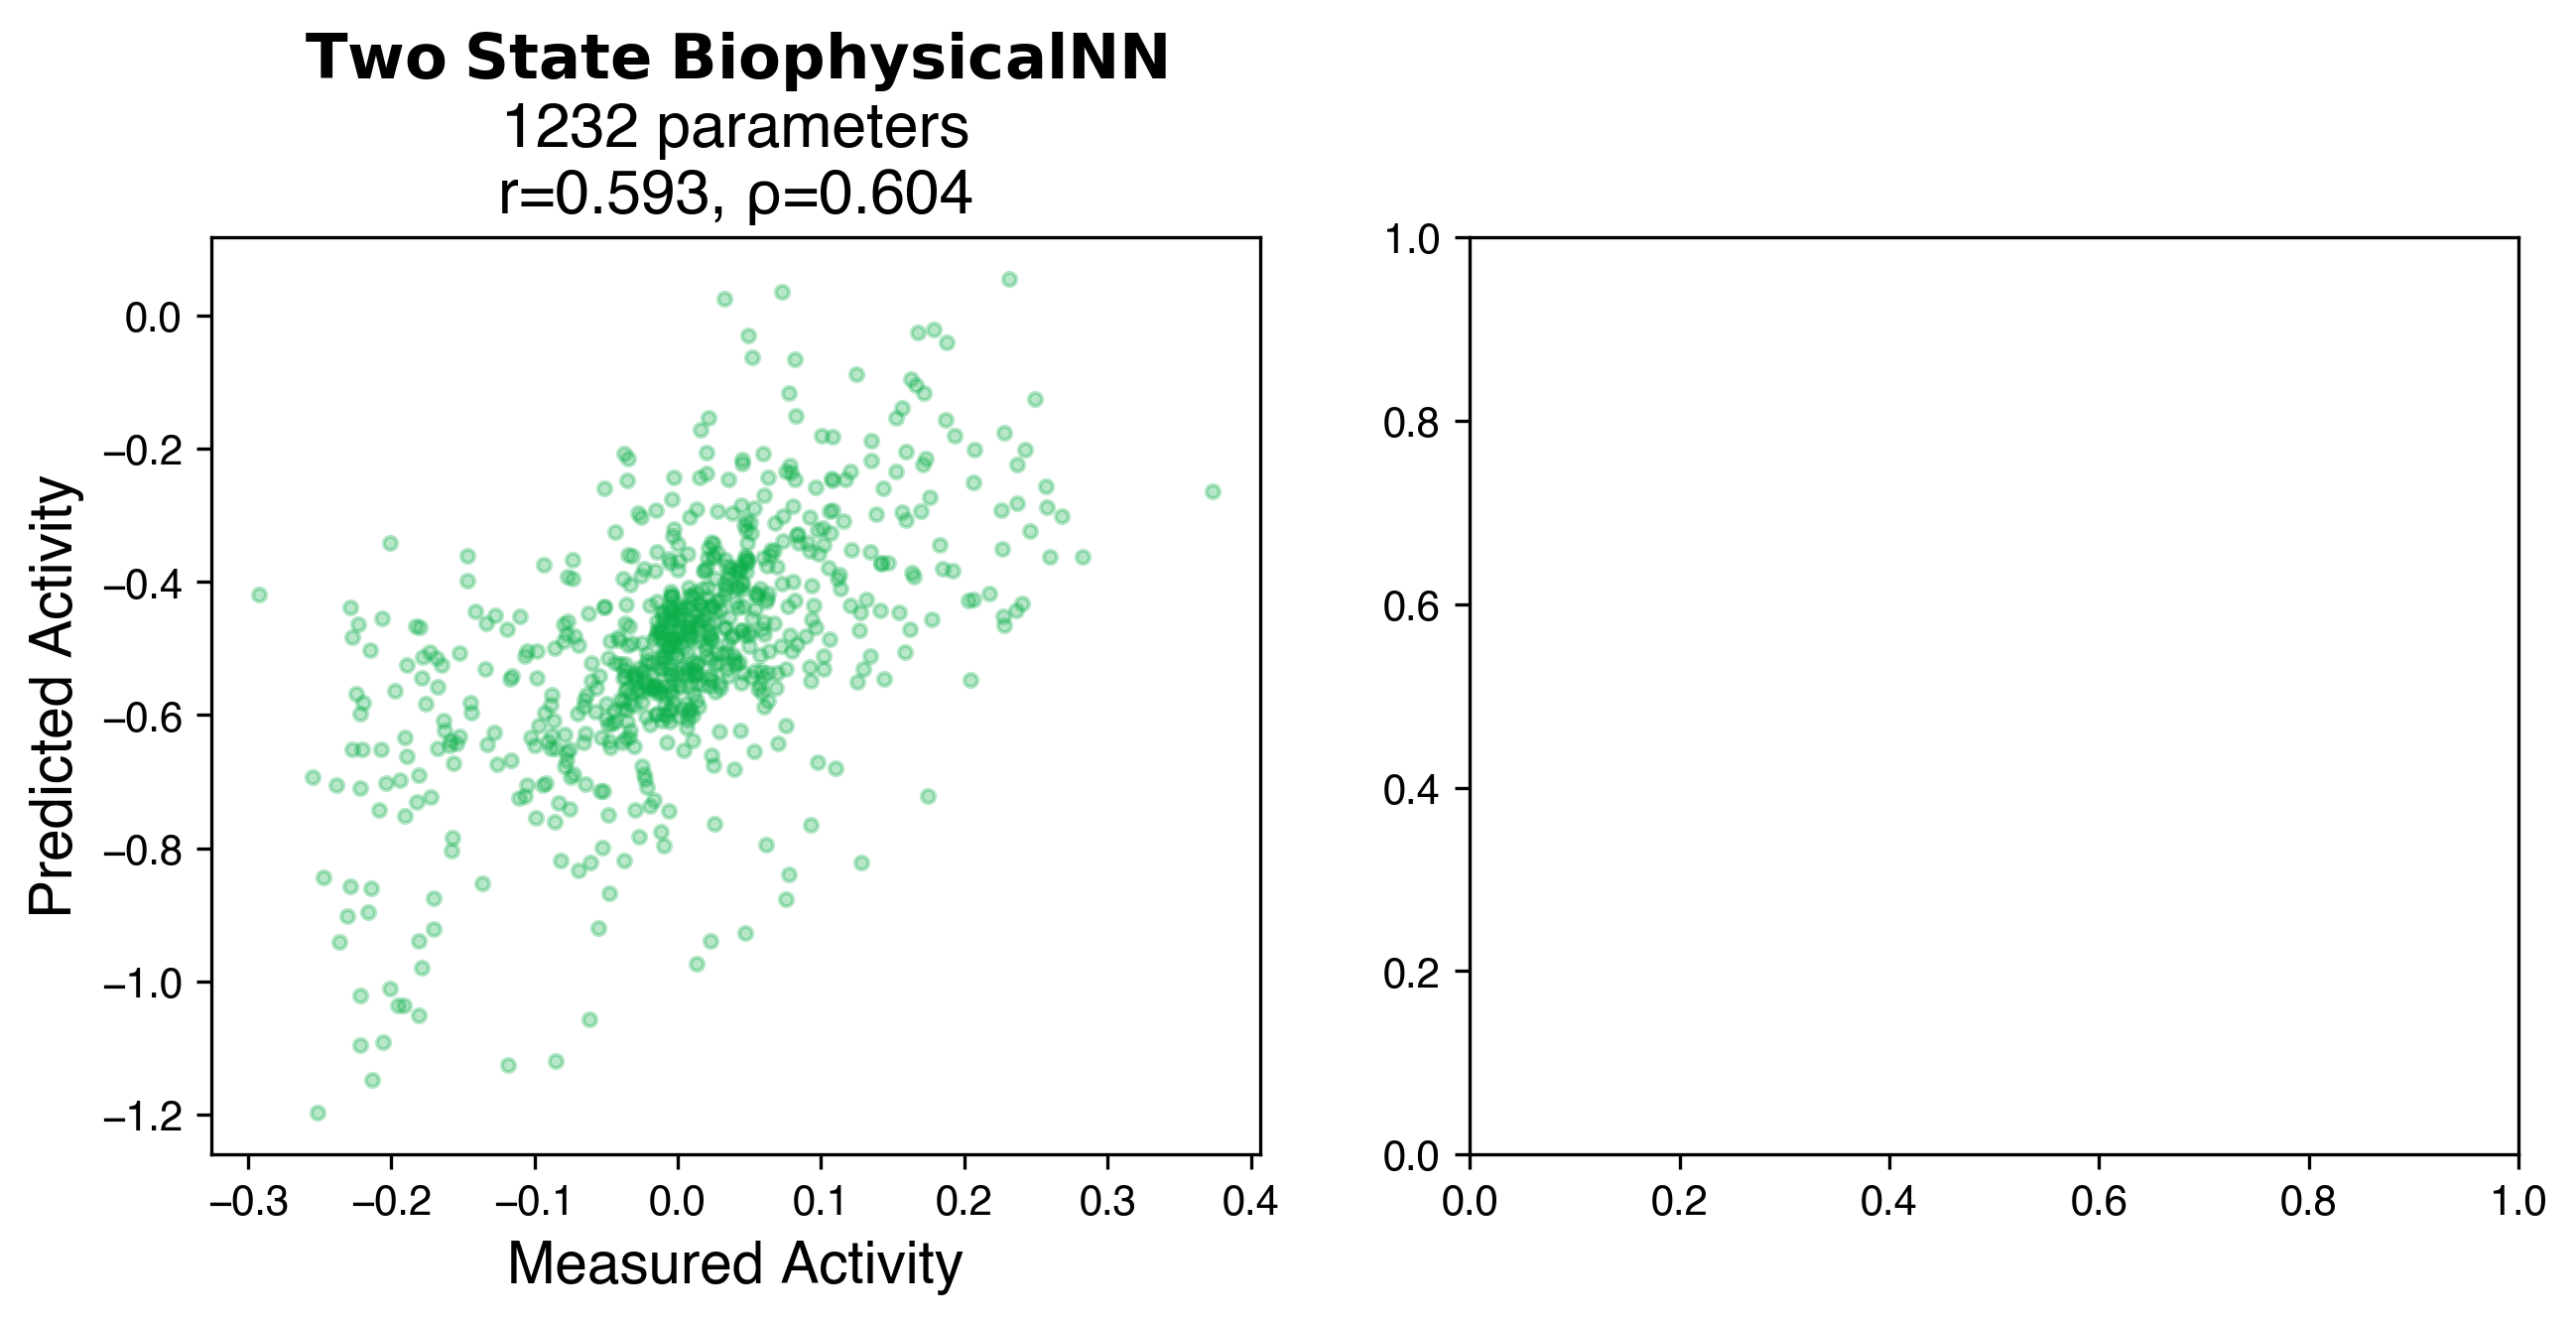

In [23]:
# Code to plot scatter plots for two-state BiophysicalNN, and ADHunter

fig, axs = plt.subplots(1,2,figsize=(10,4))

# Scatter plot for two-state BiophysicalNN - GFP
# tiles = [i for ls in test_seqs["40_tiles"] for i in ls]
# tiles = tiles + (list(other_tiles["aa_seq"]))
# actual = [i for ls in test_seqs["40_tiles_exp_activities"] for i in ls]
# actual = actual + (list(other_tiles["activity"]))
# pred = [i for ls in test_seqs["biophysics_gfp_pred_2"] for i in ls]
# pred = pred + (list(other_tiles["biophysics_gfp_pred_2"]))
plotting_data = test_seqs[['activity', 'biophysics_gfp_pred_2', 'aa_seq']]
plotting_data = plotting_data.dropna()
plotting_data.columns = ["actual", "pred", "aa_seq"]
plotting_data = plotting_data.drop_duplicates("aa_seq") 

axs[0].scatter(plotting_data['actual'], plotting_data['pred'], color='#0DB04B', s=10, alpha=0.3)
spearman = spearmanr(plotting_data["actual"], plotting_data["pred"]).correlation
pearson = pearsonr(plotting_data["actual"].astype('float'), plotting_data["pred"].astype('float')).correlation#np.corrcoef(list(plotting_data["actual"].values), list(plotting_data["pred"].values))[0, 1] ** 2
axs[0].set_xlabel('Measured Activity', fontsize=14)
axs[0].set_ylabel('Predicted Activity', fontsize=14)
axs[0].set_title(r"$\bf{Two}$ $\bf{State}$ $\bf{BiophysicalNN}$" + f'\n1232 parameters\nr={pearson:.3}, \u03C1={spearman:.3}', fontsize=15)

# Scatter plot for two-state BiophysicalNN - mCherry
# tiles = [i for ls in test_seqs["40_tiles"] for i in ls]
# tiles = tiles + (list(other_tiles["aa_seq"]))
# actual = [i for ls in test_seqs["40_tiles_exp_abundance"] for i in ls]
# actual = actual + (list(other_tiles["abundance"]))
# pred = [i for ls in test_seqs["biophysics_mcherry_pred_2"] for i in ls]
# pred = pred + (list(other_tiles["biophysics_mcherry_pred_2"]))
plotting_data = train_seqs[['abundance', 'biophysics_mcherry_pred_2', 'aa_seq']]
plotting_data = plotting_data.dropna()
plotting_data.columns = ["actual", "pred", "aa_seq"]
plotting_data = plotting_data.drop_duplicates("aa_seq") 

axs[1].scatter(plotting_data['actual'], plotting_data['pred'], color='#EE4274', s=10, alpha=0.3)
spearman = spearmanr(plotting_data["actual"], plotting_data["pred"]).correlation
pearson = pearsonr(plotting_data["actual"].astype('float'), plotting_data["pred"].astype('float')).correlation#np.corrcoef(list(plotting_data["actual"].values), list(plotting_data["pred"].values))[0, 1] ** 2
axs[1].set_xlabel('Measured Abundance', fontsize=14)
axs[1].set_ylabel('Predicted Abundance', fontsize=14)
axs[1].set_title(r"$\bf{Two}$ $\bf{State}$ $\bf{BiophysicalNN}$" + f'\n1232 parameters\nr={pearson:.3}, \u03C1={spearman:.3}', fontsize=15)

sns.despine()
# plt.savefig("figures/PADI_two_state_scatter_plots.pdf", format='pdf', bbox_inches='tight')

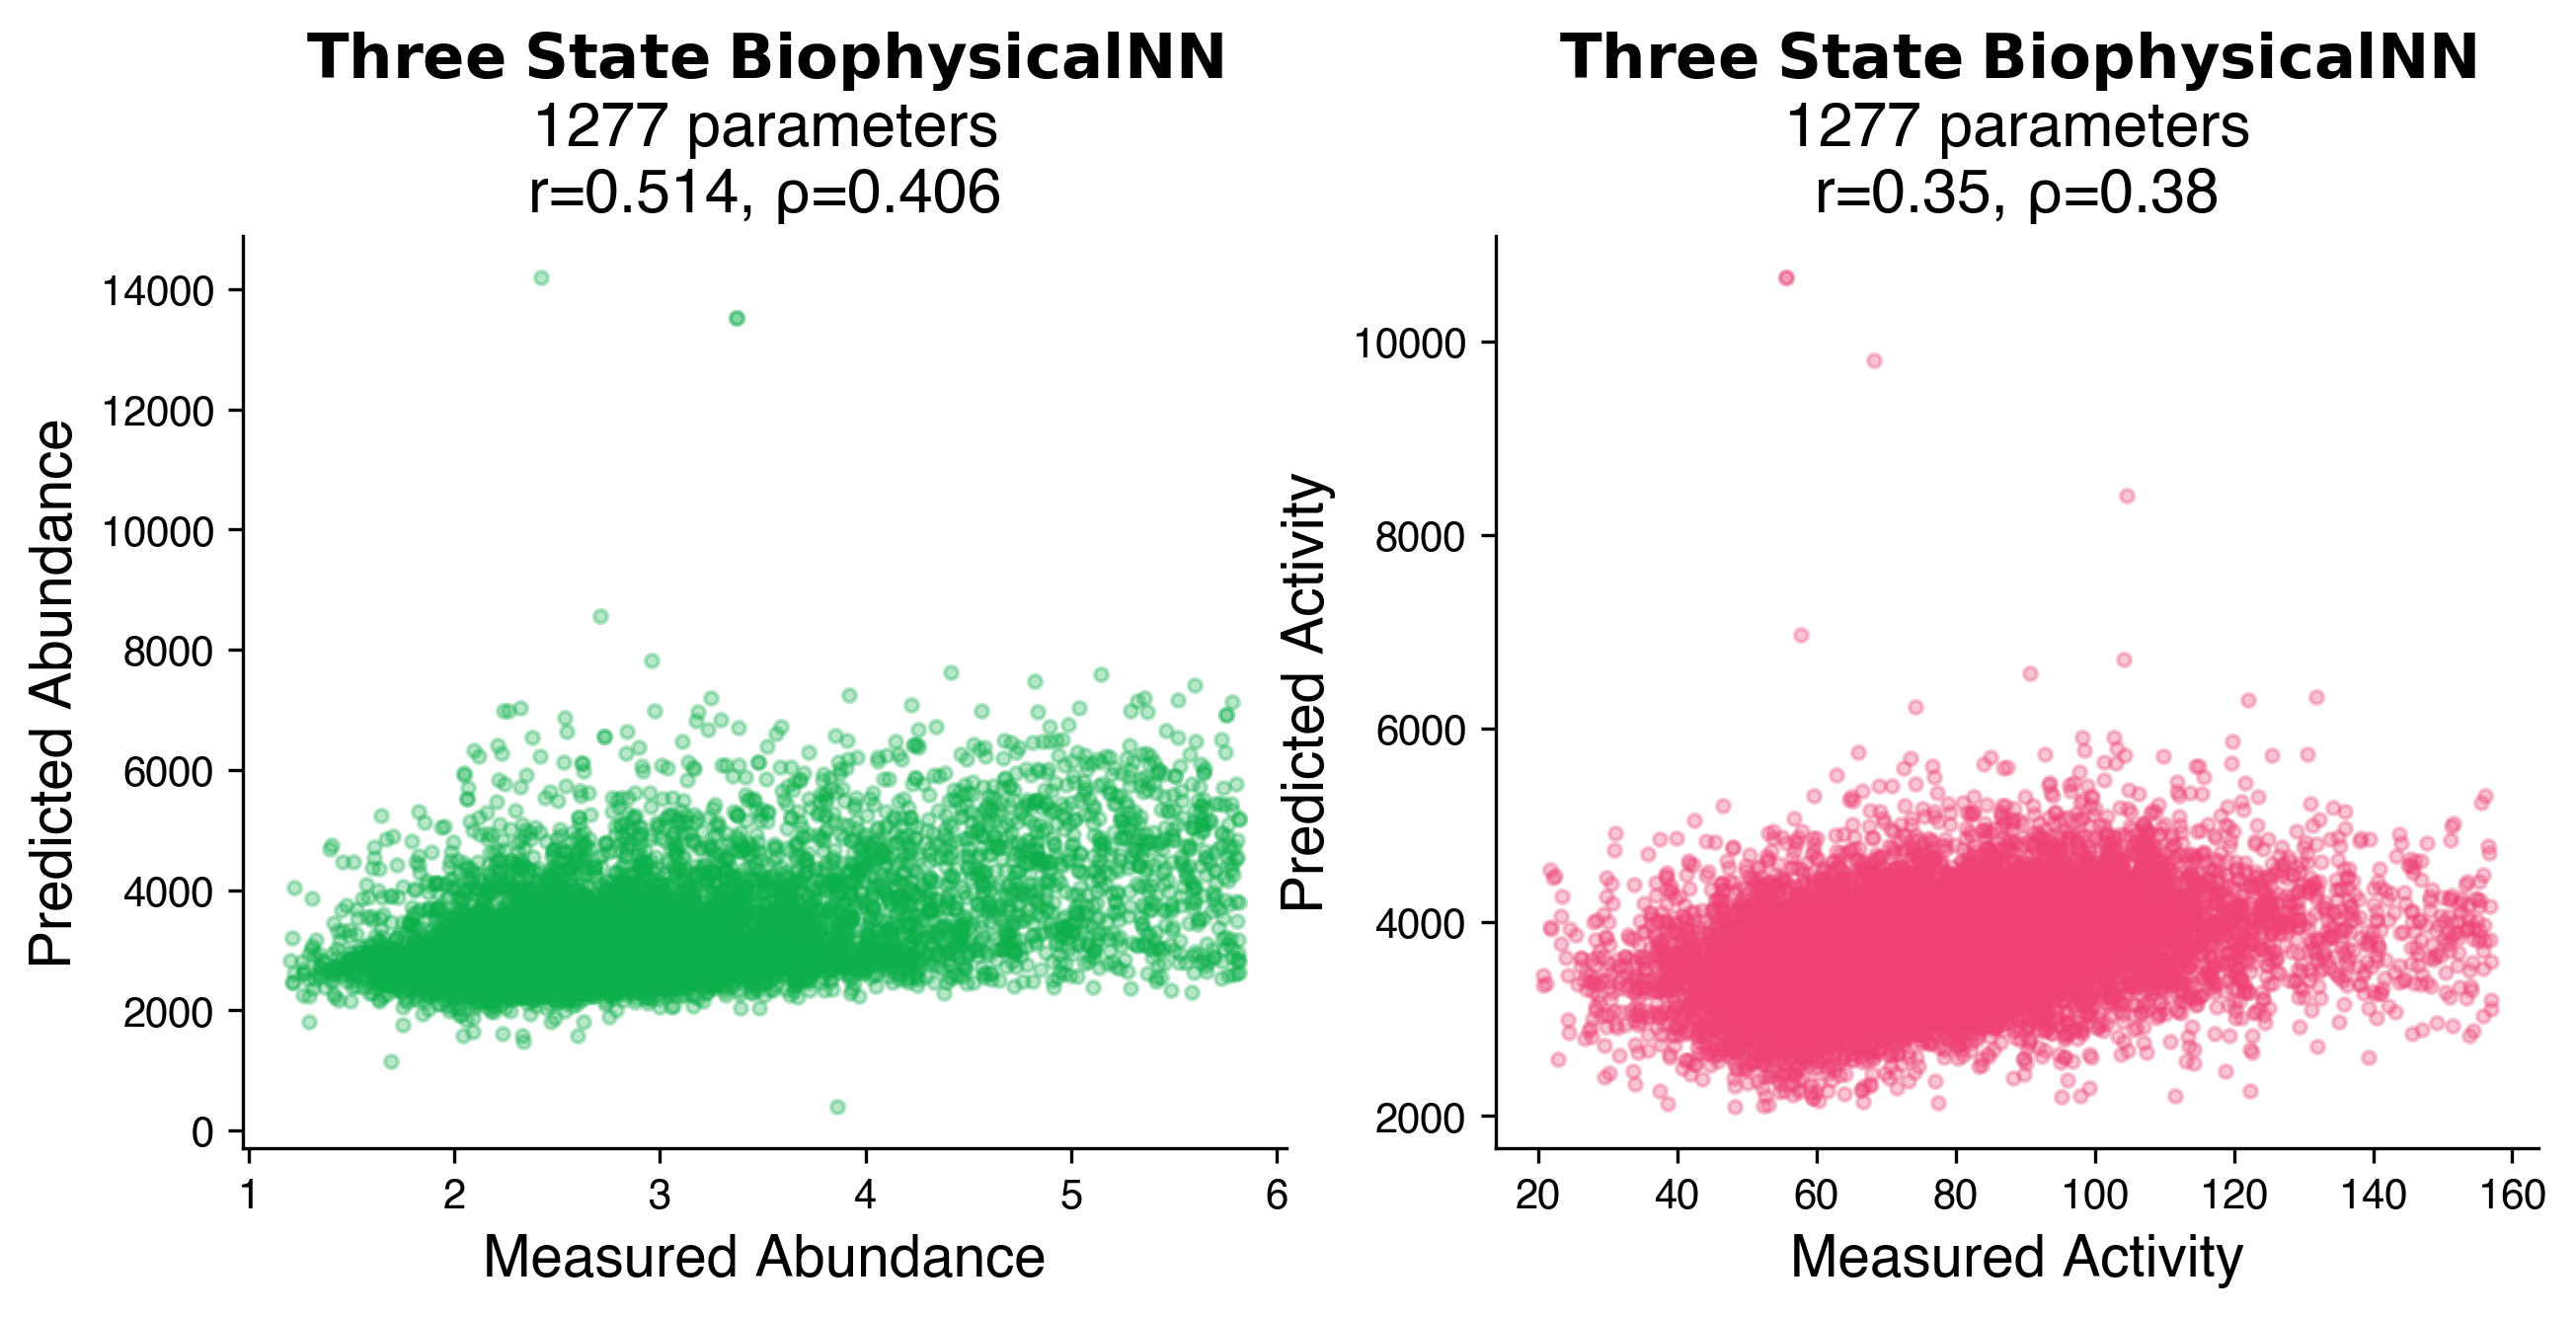

In [ ]:
# # Code to plot scatter plots for three-state BiophysicalNN, and ADHunter

# fig, axs = plt.subplots(1,2,figsize=(10,4))

# # Scatter plot for three-state BiophysicalNN - GFP
# tiles = [i for ls in test_seqs["40_tiles"] for i in ls]
# tiles = tiles + (list(other_tiles["aa_seq"]))
# actual = [i for ls in test_seqs["40_tiles_exp_abundance"] for i in ls]
# actual = actual + (list(other_tiles["abundance"]))
# pred = [i for ls in test_seqs["biophysics_mcherry_pred_3"] for i in ls]
# pred = pred + (list(other_tiles["biophysics_mcherry_pred_3"]))
# plotting_data = pd.DataFrame((actual, pred, tiles)).T
# plotting_data = plotting_data.dropna()
# plotting_data.columns = ["actual", "pred", "aa_seq"]
# plotting_data = plotting_data.drop_duplicates("aa_seq") 

# # Scatter plot for three-state BiophysicalNN - mCherry
# axs[1].scatter(actual, pred, color='#EE4274', s=10, alpha=0.3)
# spearman = spearmanr(plotting_data["actual"], plotting_data["pred"]).correlation
# pearson = pearsonr(plotting_data["actual"].astype('float'), plotting_data["pred"].astype('float')).correlation#np.corrcoef(list(plotting_data["actual"].values), list(plotting_data["pred"].values))[0, 1] ** 2
# axs[1].set_xlabel('Measured Activity', fontsize=14)
# axs[1].set_ylabel('Predicted Activity', fontsize=14)
# axs[1].set_title(r"$\bf{Three}$ $\bf{State}$ $\bf{BiophysicalNN}$" + f'\n1277 parameters\nr={pearson:.3}, \u03C1={spearman:.3}', fontsize=15)

# tiles = [i for ls in test_seqs["40_tiles"] for i in ls]
# tiles = tiles + (list(other_tiles["aa_seq"]))
# actual = [i for ls in test_seqs["40_tiles_exp_activities"] for i in ls]
# actual = actual + (list(other_tiles["activity"]))
# pred = [i for ls in test_seqs["biophysics_gfp_pred_3"] for i in ls]
# pred = pred + (list(other_tiles["biophysics_gfp_pred_3"]))
# plotting_data = pd.DataFrame((actual, pred, tiles)).T
# plotting_data = plotting_data.dropna()
# plotting_data.columns = ["actual", "pred", "aa_seq"]
# plotting_data = plotting_data.drop_duplicates("aa_seq") 

# axs[0].scatter(actual, pred, color='#0DB04B', s=10, alpha=0.3)
# spearman = spearmanr(plotting_data["actual"], plotting_data["pred"]).correlation
# pearson = pearsonr(plotting_data["actual"].astype('float'), plotting_data["pred"].astype('float')).correlation #np.corrcoef(list(plotting_data["actual"].values), list(plotting_data["pred"].values))[0, 1] ** 2
# axs[0].set_xlabel('Measured Abundance', fontsize=14)
# axs[0].set_ylabel('Predicted Abundance', fontsize=14)
# axs[0].set_title(r"$\bf{Three}$ $\bf{State}$ $\bf{BiophysicalNN}$" + f'\n1277 parameters\nr={pearson:.3}, \u03C1={spearman:.3}', fontsize=15)

# sns.despine()
# # plt.savefig(f"figures/PADI_three_state_scatter_plots.pdf", format='pdf', bbox_inches='tight')

# Inspecting the parameters of the two-state BiophysicalNN

In [24]:
# Order of AAs for plotting
amino_acids = ["R","K","H","D","E","M","I","L","V","A","F","Y","W","Q","N","S","T","G","P","C"]

def get_conv_weights(model, layer): 
    """
    Extracts the convolutional layer weights and
    returns them as a pandas dataframe
    """
    model_state_dict = model.state_dict()
    width = model_state_dict[layer].shape[0] * model_state_dict[layer].shape[2]
    conv_weight = model_state_dict[layer].detach().numpy().reshape(width,20)
    conv_weights = pd.DataFrame(conv_weight,columns = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"])
    conv_weights = conv_weights[amino_acids]
    return conv_weights

def get_linear_weights(model, layer, kernel_size):
    """
    Extracts the linear layer weights and
    returns them as a numpy array. Also returns the 
    corresponding x-axis values
    """
    linear_weights = (40 - kernel_size + 1)
    model_state_dict = model.state_dict()
    linear_weight = model_state_dict[layer].detach().numpy().reshape(linear_weights)
    x_vals = np.array(range(0,linear_weights))
    return linear_weight, x_vals


In [25]:
# This is setting up our colors for the plots

# Colors for convolutional filter
colors = [(1, 0, 0), (1, 1, 1), (0, 0, 1)]  # Red, White, Blue
n_bins = 100  # Number of color bins
cmap_name = "custom_colormap"
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)
custom_cmap.set_bad(color='white', alpha=1.0)  # Handle NaN values, if any

# Colors for AA labels
colors = {'A': 'purple', 'C': 'darkorange', 'E': 'blue', 'D': 'blue', 'G': 'darkorange', 
                  'F': 'indigo', 'I': 'purple', 'H': 'green', 'K': 'green', 'M': 'purple', 
                  'L': 'purple', 'N': 'darkslategray', 'Q': 'darkslategray', 'P': 'darkorange', 'S': 'darkslategray', 
                  'R': 'green', 'T': 'darkslategray', 'W': 'indigo', 'V': 'purple', 'Y': 'indigo'}

In [26]:
def make_row_plot_abund(fig, kernel_size, model, row, lim, height_ratios, num_rows, abund_kernel_size):
    """
    Core functionality for creating the convolutional filter plots. 
    Plots the convolution filter as a heatmap and the linear weights as a bar plot.

    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Figure object created with plt.figure
    
    kernel_size : int
        The size of the convolutional filter

    model : ADModel_abund
        Loaded model (from which parameters will be extracted)
    
    row : int
        Which row in the overall figure should we fill in

    lim : float
        The max value for the heatmap

    height_ratios : list
        Ratio of heights between rows, length should correspond to number of rows in
        gridspec object

    num_rows : list
        The number of rows in the gridspec object

    Returns
    -------
    ax1 : maplotlib.Axes object
        Contains the heatmap
    ax2 : maplotlib.Axes object
        Contains the barplot
    im1 : maplotlib.Axes.imshow object
        The heatmap
    """

    # Load the convolutional and linear weights for both NN blocks
    model_conv1 = get_conv_weights(model, "conv1.weight").T
    model_linear1, model_xvals1 = get_linear_weights(model, "linear1.weight", kernel_size)

    model_conv2 = get_conv_weights(model, "conv2.weight").T
    model_linear2, model_xvals2 = get_linear_weights(model, "linear2.weight", abund_kernel_size)

    # Calculate how much of the figure the convolutional filters vs. linear weights will take up
    ratio1 = kernel_size 
    ratio2 = 56 - kernel_size + 1
    ratio1_abund = abund_kernel_size
    ratio2_abund = 56 - abund_kernel_size + 1

    # GridSpec allows us to plot rows/columns with different dimensions
    # Here, we initalize the gridspec object with the total number of rows in our figure
    # But we only fill in the specific row that we are interested in
    # (When combined with many other gridspec objects, they will all line up and look good)
    gs1 = gridspec.GridSpec(2 + num_rows, 5, width_ratios=[ratio1, ratio2, 0.5, ratio1_abund, ratio2_abund], height_ratios=height_ratios, figure=fig)
    
    # axs are matplotlib axes
    ax1 = plt.subplot(gs1[row, 0])
    ax2 = plt.subplot(gs1[row, 1])
    ax3 = plt.subplot(gs1[row, 3])
    ax4 = plt.subplot(gs1[row, 4])


    ## Code for first set of parameters --> K1 predictor
    # This is the code for plotting the convolutional filter as a heatmap
    # Min and max values of heatmap are passed by used
    im1 = ax1.imshow(model_conv1.to_numpy(), cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
    ax1.set_yticks(range(len(model_conv1.index)), model_conv1.index)  # Label x-axis with column names
    ax1.set_xticks(np.arange(kernel_size, step=2))

    # This is to color the amino acid labels
    for ytic in ax1.get_yticklabels():
        if ytic.get_text() in colors.keys(): 
            ytic.set_color(colors[ytic.get_text()])
    ax1.tick_params(axis='both', which='major', labelsize=6) 

    # This is the code for plotting the linear weights as a bar graph
    ax2.bar(model_xvals1, model_linear1, color="grey")
    ax2.spines["top"].set_visible(False)
    ax2.spines["left"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    ax2.spines["bottom"].set_position('zero')
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.set_xticklabels([])
    ax2.set_yticklabels([])

    ## Code for second set of parameters --> abundance predictor
    # This is the code for plotting the convolutional filter as a heatmap
    # Min and max values of heatmap are passed by used
    im2 = ax3.imshow(model_conv2.to_numpy(), cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
    ax3.set_yticks(range(len(model_conv2.index)), model_conv2.index)  # Label x-axis with column names
    ax3.set_xticks(np.arange(abund_kernel_size, step=2))
    
    # This is to color the amino acid labels
    for ytic in ax3.get_yticklabels():
        if ytic.get_text() in colors.keys(): 
            ytic.set_color(colors[ytic.get_text()])
    ax3.tick_params(axis='both', which='major', labelsize=6) 

    # This is the code for plotting the linear weights as a bar graph
    ax4.bar(model_xvals2, model_linear2, color="grey")
    ax4.spines["top"].set_visible(False)
    ax4.spines["left"].set_visible(False)
    ax4.spines["right"].set_visible(False)
    ax4.spines["bottom"].set_position('zero')
    ax4.set_xticks([])
    ax4.set_yticks([])
    ax4.set_xticklabels([])
    ax4.set_yticklabels([])


    return ax1, ax2, ax3, ax4, im1, im2


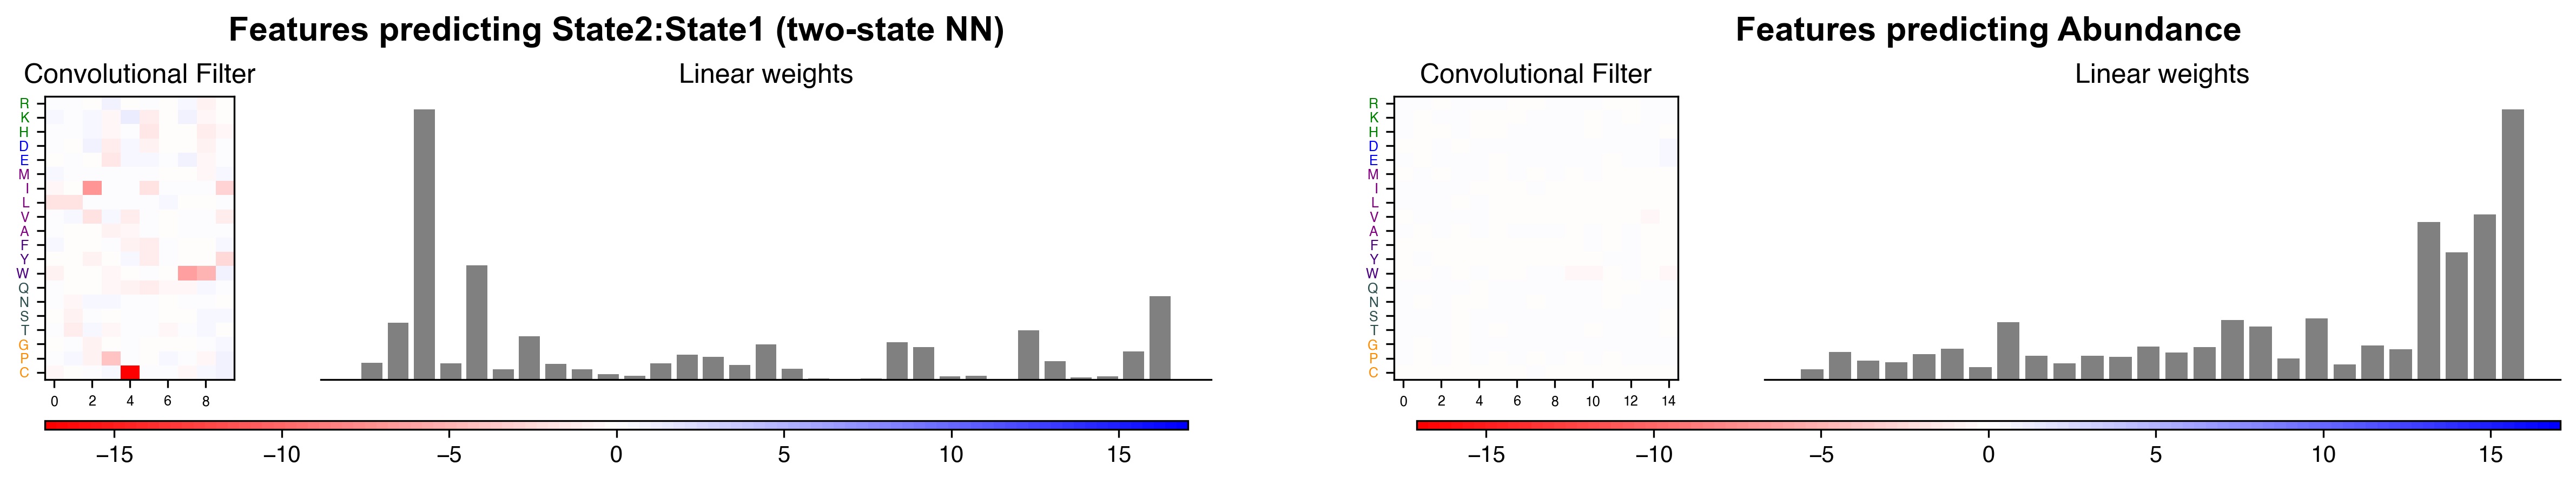

In [27]:
# Get the range for the heatmaps
models = [two_state_biophysical_model]
conv_weights = []

for model in models: 
    conv_weights += list(get_conv_weights(model, "conv1.weight").T.values.flatten())
    conv_weights += list(get_conv_weights(model, "conv2.weight").T.values.flatten())

# Max value for heatmaps
lim = max([abs(w) for w in conv_weights])

num_rows = 1

# Create a figure
fig = plt.figure(figsize=(20, 3*num_rows))
title_font = {'fontsize': 15, 'fontweight': 'bold', 'fontname': 'Arial'}

# We add in "padding" rows between the rows we care about
height_ratios = [.3] + [3.3]*num_rows + [.1]*2

# Create a gridspec object
gs1 = gridspec.GridSpec(3 + num_rows, 2, width_ratios=[1,1], height_ratios=height_ratios, figure=fig)

# Making the first row a title row
ax1 = plt.subplot(gs1[0,0])
ax1.set_title("Features predicting State2:State1 (two-state NN)", fontdict=title_font)
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_xticklabels([])
ax1.set_yticklabels([])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.patch.set_visible(False)
ax1.axis('off')

ax2 = plt.subplot(gs1[0,1])
ax2.set_title("Features predicting Abundance", fontdict=title_font)
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_xticklabels([])
ax2.set_yticklabels([])
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.patch.set_visible(False)
ax2.axis('off')

# Adding the best NN parameters to the first row
ax1, ax2, ax3, ax4, im1, im2 = make_row_plot_abund(fig, kernel_size_two, two_state_biophysical_model, 1, lim, height_ratios, num_rows+1, abund_k_two)

ax1.set_title("Convolutional Filter", fontsize=12)
ax2.set_title("Linear weights", fontsize=12)
ax3.set_title("Convolutional Filter", fontsize=12)
ax4.set_title("Linear weights", fontsize=12)

# Create another gridspec object to span the whole figure (1 column) to display the colorbar
gs_cb = gridspec.GridSpec(3 + num_rows, 2, width_ratios=[1,1], height_ratios=height_ratios, figure=fig)
cax1 = plt.subplot(gs_cb[2 + num_rows, 0])
cax2 = plt.subplot(gs_cb[2 + num_rows, 1])

# Add the colorbar
fig.colorbar(im1,cax=cax1, orientation='horizontal')
fig.colorbar(im2, cax=cax2, orientation='horizontal')

# plt.savefig('figures/PADI_two_state_parameters.pdf', dpi=1000, bbox_inches='tight')

In [17]:
np.abs(conv_weights)

array([0.044, 0.113, 0.019, ..., 0.009, 0.034, 0.046], dtype=float32)

<BarContainer object of 20 artists>

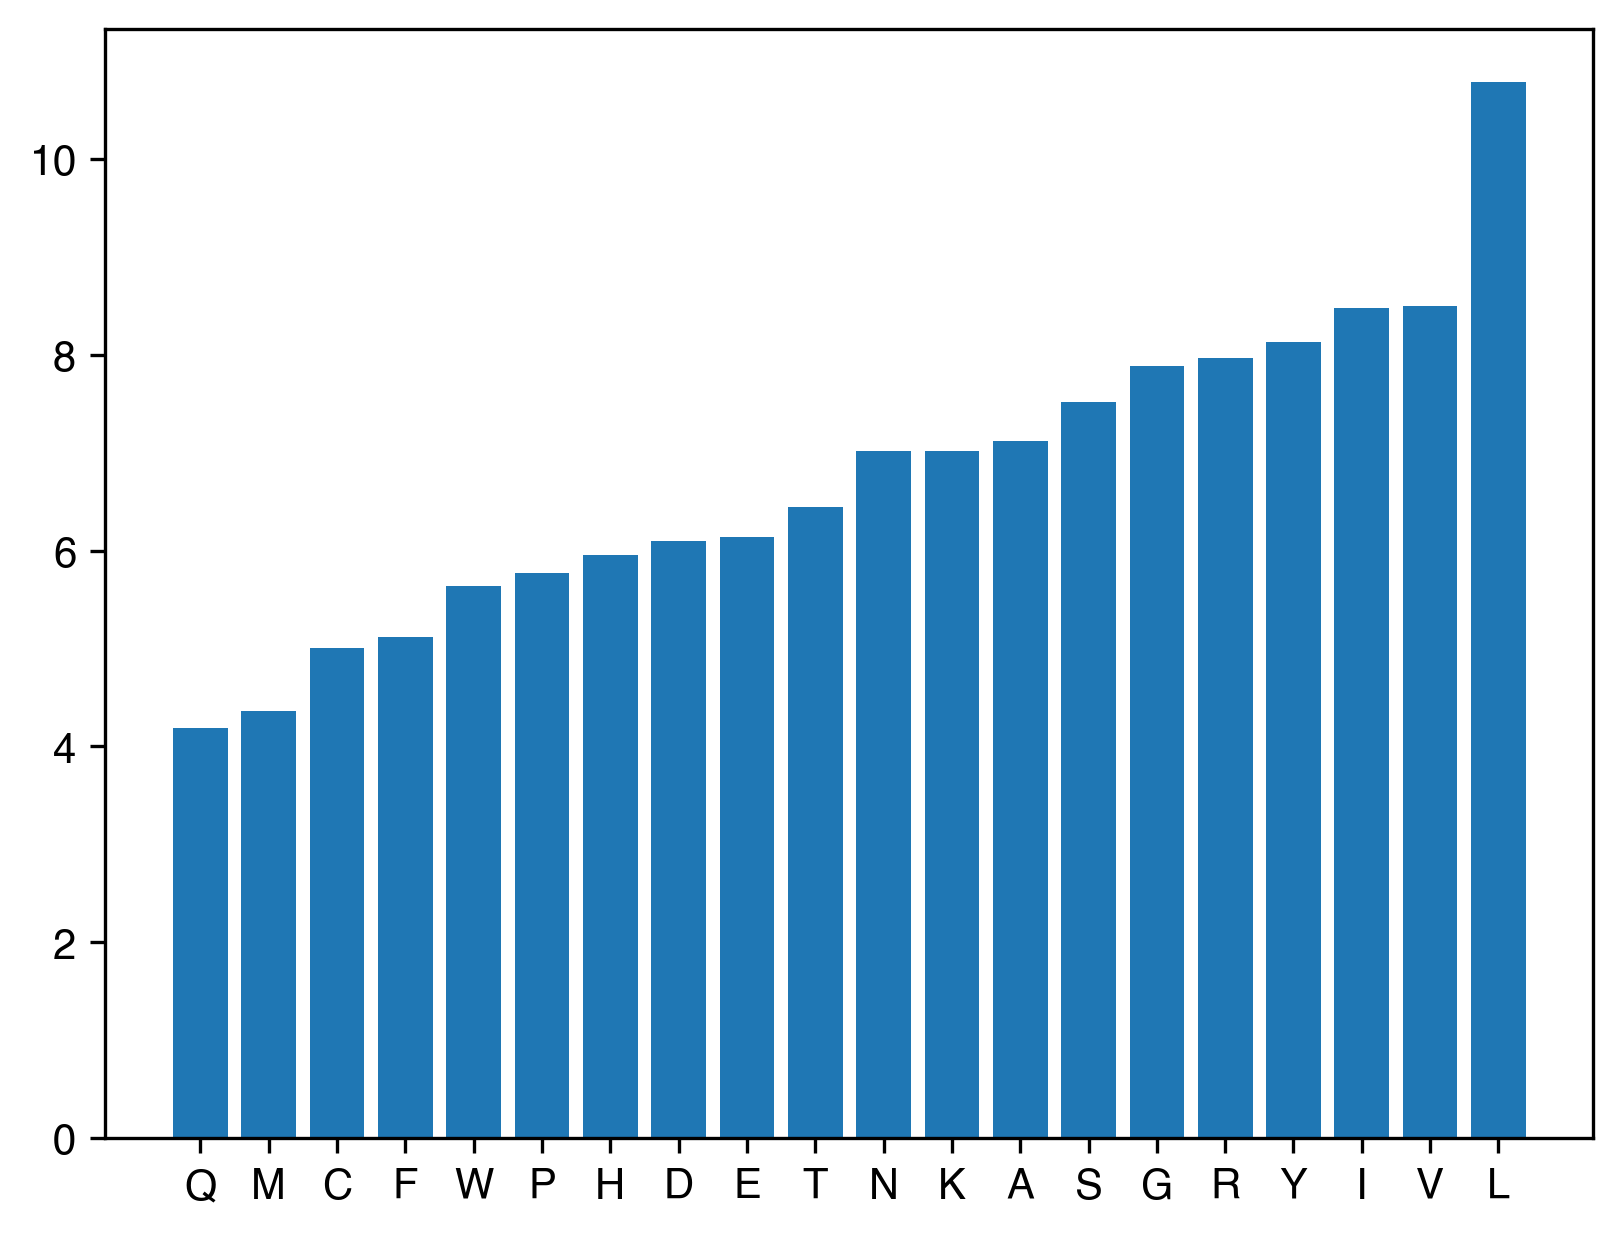

In [18]:
conv_weights = get_conv_weights(two_state_biophysical_model, layer='conv1.weight')

# Control could be to shuffle row wise
plt.bar(np.abs(conv_weights).sum().sort_values().index, height=np.abs(conv_weights).sum().sort_values())

# Compare with their results

In [203]:
# Our data
all_seqs = pd.concat([train_seqs, val_seqs, test_seqs])

R = 8.314
T = 303

all_seqs['delta_G_b'] = [-R * T * np.log(K) for K in all_seqs["K1"]]

In [ ]:
WT_seq = "TYVQALFDFDPQEDGELGFRRGDFIHVMDNSDPNWWKGACHGQTGMFPRNYVTPVN"

True

In [255]:
# Their data
inferred_delta_G = pd.read_csv('/Users/claireleblanc/Downloads/41586_2022_4586_MOESM10_ESM.csv')
inferred_delta_G = inferred_delta_G[inferred_delta_G['protein'] == "GRB2-SH3"]

inferred_delta_G["aa_seq"] = [WT_seq[:int(inferred_delta_G.loc[i, 'Pos']) - 1] + inferred_delta_G.loc[i, 'Mut'] + WT_seq[int(inferred_delta_G.loc[i, 'Pos']):] if not np.isnan(inferred_delta_G.loc[i, 'Pos']) else WT_seq for i in inferred_delta_G.index]

# Missing all double mutants and sequences with no binding data
merged_data = inferred_delta_G.merge(all_seqs, on='aa_seq')
merged_data = merged_data[merged_data['b_ddg_pred_conf']]

In [256]:
merged_data['Pos_class'].value_counts()

Pos_class
surface              318
binding_interface    107
core                 105
Name: count, dtype: int64

SignificanceResult(statistic=-0.8733321577617117, pvalue=1.4129896265753356e-34)

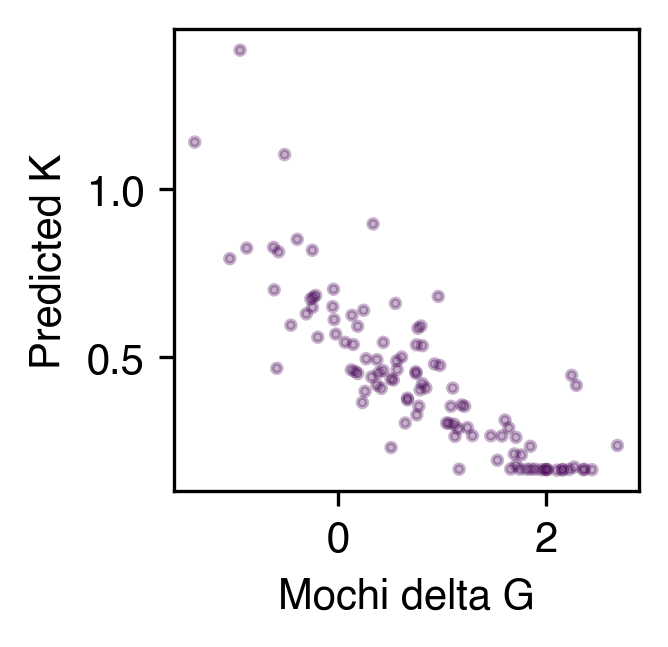

In [266]:
plt.figure(figsize=(2, 2))
merged_data_subset = merged_data[merged_data['Pos_class'] == 'binding_interface']
plt.scatter(merged_data_subset['b_ddg_pred'], merged_data_subset['K1'], s=5, alpha=0.3, c=merged_data_subset['Pos_class'].astype('category').cat.codes, cmap='viridis')
plt.xlabel("Mochi delta G")
plt.ylabel("Predicted K")
spearmanr(merged_data_subset['b_ddg_pred'], merged_data_subset['K1'])


In [19]:
params = pd.read_table('/Users/claireleblanc/Downloads/Data/mochi/GRB2-SH3/mochi__fit_tmodel_3state_sparse_dimsum128/model_weights_0.txt')

In [109]:
params

,id,folding_coefficient,binding_coefficient,orig_AA,new_AA,location
0,WT,-1.381041,-1.735641,W,T,-1
1,T1A,0.410387,-0.012502,T,A,1
2,T1C,-0.077142,NaN,T,C,1
3,T1D,0.165963,NaN,T,D,1
4,T1E,0.093960,-0.038914,T,E,1
...,...,...,...,...,...,...
1052,N56S,0.406629,0.276497,N,S,56
1053,N56T,0.167101,-0.023820,N,T,56
1054,N56V,0.435150,-0.289166,N,V,56
1055,N56W,0.688179,NaN,N,W,56


In [44]:
params['orig_AA'] = params['id'].str[0]
params['new_AA'] = params['id'].str[-1]
params['location'] = [int(re.findall("\d+", s)[0]) if s != "WT" else -1 for s in params['id']]

In [45]:
binding_data = params.pivot(columns="location", index='new_AA', values='binding_coefficient').loc[amino_acids]

In [293]:
binding_data

location,-1,1,2,3,4,5,6,7,8,9,...,47,48,49,50,51,52,53,54,55,56
new_AA,,,,,,,,,,,,,,,,,,,,,
R,NaN,0.411384,0.071913,NaN,-0.001877,NaN,0.295973,NaN,-1.433393,NaN,...,NaN,1.972470,NaN,1.695888,1.938787,NaN,-0.683829,0.269784,-0.876691,-0.095500
K,NaN,0.027083,0.132176,NaN,0.210727,NaN,NaN,NaN,-1.177519,NaN,...,NaN,NaN,NaN,1.917059,-1.583332,NaN,0.059968,NaN,1.233893,0.092536
H,NaN,NaN,-0.111500,-3.181988,-0.199598,NaN,0.647357,1.071207,-0.263846,1.746801,...,0.304357,2.926097,-0.473035,0.841607,-0.394212,NaN,NaN,-0.123117,NaN,0.221541
D,NaN,NaN,0.798801,2.907636,NaN,1.263196,NaN,NaN,NaN,NaN,...,0.024131,NaN,-4.310266,0.240225,-0.166571,3.514520,-4.561535,-0.176107,0.006808,0.127942
E,NaN,-0.038914,NaN,0.767888,-0.159426,-2.411614,NaN,NaN,-0.305186,NaN,...,NaN,NaN,NaN,0.386959,NaN,2.221125,NaN,NaN,0.160491,-0.150943
M,NaN,-0.149663,NaN,NaN,0.549505,NaN,NaN,1.498892,NaN,9.682658,...,NaN,NaN,NaN,1.768463,NaN,-2.950778,0.087027,NaN,0.336783,0.136374
I,NaN,0.125236,-0.130781,0.782587,NaN,-0.636673,0.259847,3.934629,-1.312897,3.768303,...,0.141443,1.487000,-0.664872,1.344108,1.931087,-0.157711,0.663237,0.480173,-0.064496,0.263591
L,NaN,0.115411,-0.409850,-0.148650,0.533747,NaN,NaN,3.245368,NaN,2.664117,...,-0.172116,1.623718,-0.750043,-0.400897,2.614350,0.466058,NaN,-0.026879,0.386122,NaN
V,NaN,-0.527461,NaN,NaN,0.512944,1.478605,0.903001,3.325831,0.881970,4.052858,...,0.662715,NaN,NaN,1.288632,2.144913,NaN,0.729151,0.946371,NaN,-0.289166


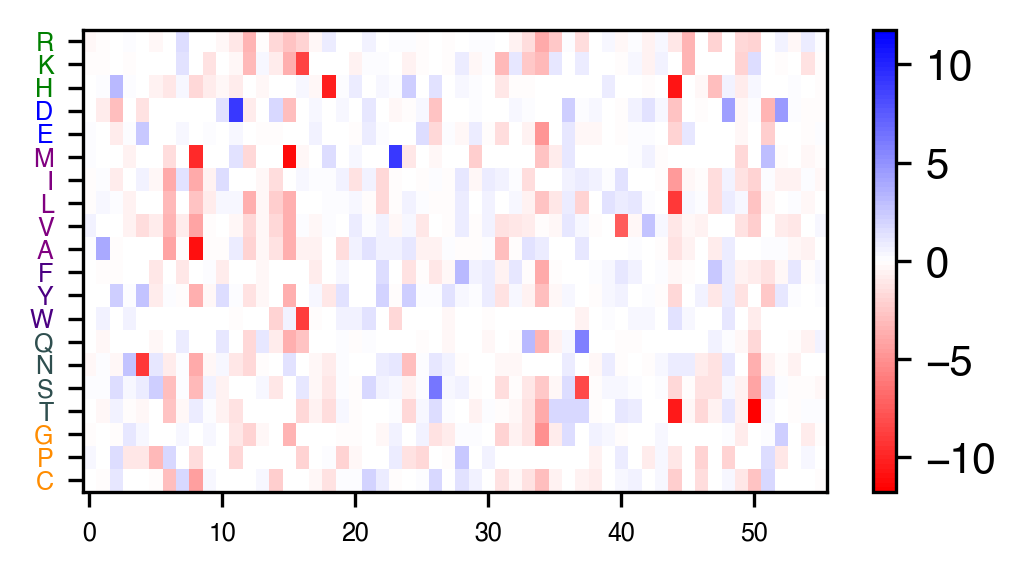

In [295]:
lim = max(np.abs(binding_data.min().min()), np.abs(binding_data.max().max()))
fig, ax1 = plt.subplots(1, 1, figsize=(4, 2))
im1 = ax1.imshow(binding_data.drop(columns=[-1]).to_numpy() * -1, cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
ax1.set_yticks(range(len(binding_data.index)), binding_data.index)  # Label x-axis with column names
# ax1.set_xticks(np.arange(kernel_size, step=2))

# This is to color the amino acid labels
for ytic in ax1.get_yticklabels():
    if ytic.get_text() in colors.keys(): 
        ytic.set_color(colors[ytic.get_text()])
ax1.tick_params(axis='both', which='major', labelsize=6) 

plt.colorbar(im1)

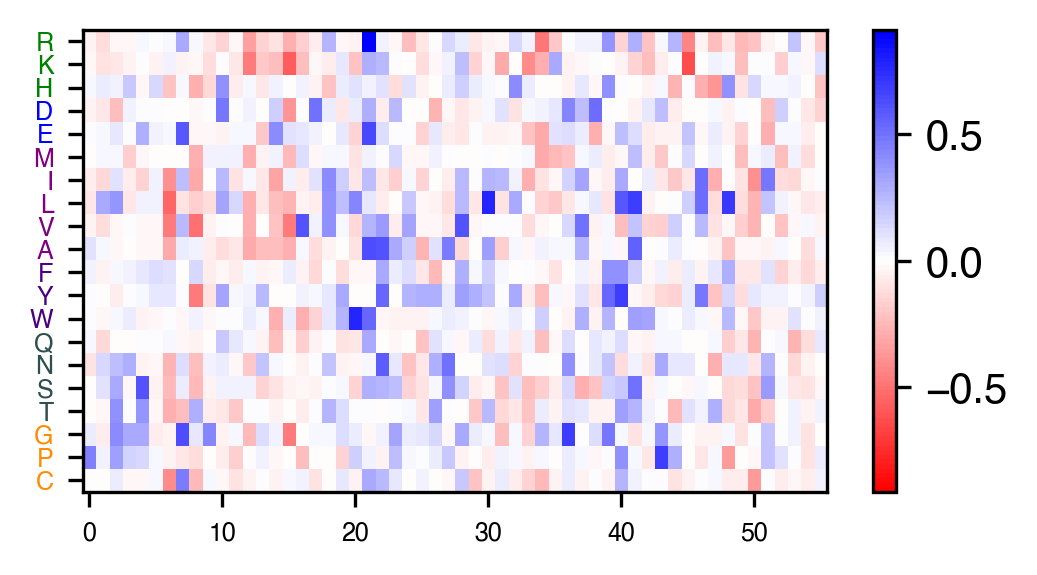

In [291]:
lim = max(np.abs(conv_weights.min().min()), np.abs(conv_weights.max().max()))

fig, ax1 = plt.subplots(1, 1, figsize=(4, 2))
im1 = ax1.imshow(conv_weights.T.to_numpy(), cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
ax1.set_yticks(range(len(conv_weights.T.index)), conv_weights.T.index)  # Label x-axis with column names
# ax1.set_xticks(np.arange(kernel_size, step=2))

# This is to color the amino acid labels
for ytic in ax1.get_yticklabels():
    if ytic.get_text() in colors.keys(): 
        ytic.set_color(colors[ytic.get_text()])
ax1.tick_params(axis='both', which='major', labelsize=6) 

plt.colorbar(im1)

In [147]:
train_seqs['delta_G_b']

0        524.416922
1       2341.749004
2       -684.381518
3       1486.983949
4       -677.311849
           ...     
4261    3061.794403
4262     498.252472
4263    2816.742793
4264    2583.103899
4265     230.736354
Name: delta_G_b, Length: 4266, dtype: float64

In [279]:
our_weights = conv_weights.T.values.flatten()
their_weights = binding_data.drop(columns=[-1]).values.flatten()

PearsonRResult(statistic=-0.4498984516573368, pvalue=6.011624351275197e-39)


(-5.0, 5.0)

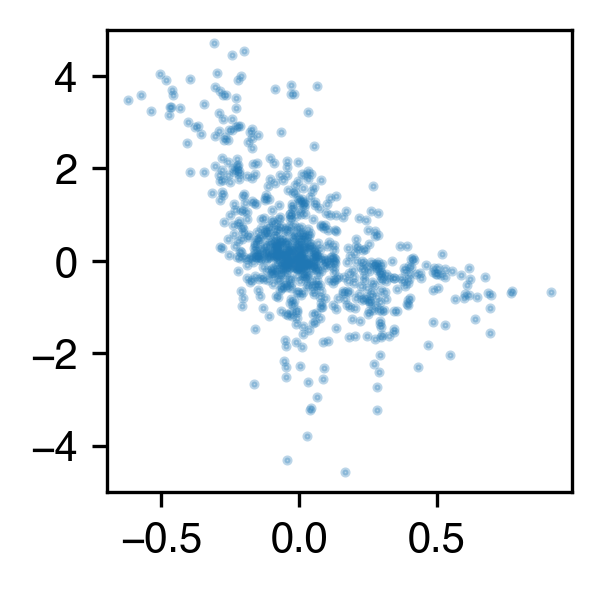

In [286]:
i = 50
df = pd.DataFrame({'ours' : our_weights, 'theirs' : their_weights}).dropna()
print(pearsonr(df['ours'], df['theirs']))
plt.figure(figsize=(2, 2))
plt.scatter(df['ours'], df['theirs'], s=2, alpha=0.3)
plt.ylim(-5, 5)

In [89]:
import tensorflow as tf

model_dir = "/Users/claireleblanc/Downloads/Data/mochi/GRB2-SH3/mochi__fit_tmodel_3state_sparse_dimsum128/whole_model/my_model_0/"
loaded = tf.saved_model.load(model_dir)

In [96]:
keras_model = tf.keras.models.load_model(model_dir)
keras_model.summary()

Model: "functional_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_fold (InputLayer)        [(None, 1057)]       0           []                               
                                                                                                  
 input_bind (InputLayer)        [(None, 757)]        0           []                               
                                                                                                  
 folding_additivetrait (Dense)  (None, 1)            1057        ['input_fold[0][0]']             
                                                                                                  
 binding_additivetrait (Dense)  (None, 1)            757         ['input_bind[0][0]']             
                                                                                       

In [119]:
additive_weights = keras_model.get_layer('folding_additivetrait').get_weights()
binding_additive_weights = keras_model.get_layer('binding_additivetrait').get_weights()

In [123]:
keras_model.get_layer('state_prob_bound').get_weights()

[]

NameError: name 'K' is not defined

In [121]:
binding_additive_weights[0]

array([[-1.736],
       [-0.013],
       [-0.039],
       [0.184],
       [0.125],
       [0.027],
       [0.115],
       [-0.150],
       [0.417],
       [-0.361],
       [0.411],
       [-0.020],
       [-0.527],
       [-3.782],
       [0.023],
       [0.799],
       [0.128],
       [-0.111],
       [-0.131],
       [0.132],
       [-0.410],
       [-0.051],
       [0.262],
       [0.072],
       [-0.055],
       [0.448],
       [-0.592],
       [0.123],
       [-1.121],
       [2.908],
       [0.768],
       [0.036],
       [0.065],
       [-3.182],
       [0.783],
       [-0.149],
       [0.244],
       [-1.548],
       [-1.615],
       [-0.546],
       [-2.174],
       [-0.159],
       [-1.079],
       [-0.200],
       [0.211],
       [0.534],
       [0.550],
       [-2.725],
       [0.947],
       [-0.002],
       [-0.370],
       [0.143],
       [0.513],
       [-0.530],
       [-0.104],
       [1.263],
       [-2.412],
       [-0.374],
       [-0.637],
       [8.964],
       [

In [120]:
params['NN_weights_folding'] = additive_weights[0]
params['NN_weights_binding'] = binding_additive_weights[0]
params

ValueError: Length of values (757) does not match length of index (1057)

# Making convolutional filter plots -> Three state

In [ ]:
# Same colors as before, not sure why I'm redefinint them here

colors = [(1, 0, 0), (1, 1, 1), (0, 0, 1)]  # Red, White, Blue
n_bins = 100  # Number of color bins
cmap_name = "custom_colormap"
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)
custom_cmap.set_bad(color='white', alpha=1.0)  # Handle NaN values, if any
colors = {'A': 'purple', 'C': 'darkorange', 'E': 'blue', 'D': 'blue', 'G': 'darkorange', 
                  'F': 'indigo', 'I': 'purple', 'H': 'green', 'K': 'green', 'M': 'purple', 
                  'L': 'purple', 'N': 'darkslategray', 'Q': 'darkslategray', 'P': 'darkorange', 'S': 'darkslategray', 
                  'R': 'green', 'T': 'darkslategray', 'W': 'indigo', 'V': 'purple', 'Y': 'indigo'}

In [ ]:
def make_row_plot_abund(fig, kernel_size, model, row, lim, height_ratios, num_rows, abund_kernel_size):
    """
    Core functionality for creating the convolutional filter plots. 
    Plots the convolution filter as a heatmap and the linear weights as a bar plot.

    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Figure object created with plt.figure
    
    kernel_size : int
        The size of the convolutional filter

    model : ADModel_abund
        Loaded model (from which parameters will be extracted)
    
    row : int
        Which row in the overall figure should we fill in

    lim : float
        The max value for the heatmap

    height_ratios : list
        Ratio of heights between rows, length should correspond to number of rows in
        gridspec object

    num_rows : list
        The number of rows in the gridspec object
    
    abund_kernel_size : int
        The size of the abundance kernel (can be different from other kernel sizes)

    Returns
    -------
    ax1-6 : maplotlib.Axes object
        Contains the heatmaps and barplots
    im1-3 : maplotlib.Axes.imshow object
        The heatmaps
    """

    # Load the parameters for the K1 module
    model_conv1 = get_conv_weights(model, "conv1.weight").T
    model_linear1, model_xvals1 = get_linear_weights(model, "linear1.weight", kernel_size)

    # Load the parameters for the K2 module
    model_conv2 = get_conv_weights(model, "conv2.weight").T
    model_linear2, model_xvals2 = get_linear_weights(model, "linear2.weight", kernel_size)

    # Load the parameters for the abundance module
    model_conv3 = get_conv_weights(model, "conv3.weight").T
    model_linear3, model_xvals3 = get_linear_weights(model, "linear3.weight", abund_kernel_size)

    # Calculate how much of the figure the convolutional filter vs. linear weights will take up
    ratio1 = kernel_size 
    ratio2 = 40 - kernel_size + 1
    ratio1_abund = abund_kernel_size
    ratio2_abund = 40 - abund_kernel_size + 1

    # GridSpec allows us to plot rows/columns with different dimensions
    # Here, we initalize the gridspec object with the total number of rows in our figure
    # But we only fill in the specific row that we are interested in
    # (When combined with many other gridspec objects, they will all line up and look good)
    gs1 = gridspec.GridSpec(2 + num_rows, 8, width_ratios=[ratio1, ratio2, 0.5, ratio1, ratio2, 0.5, ratio1_abund, ratio2_abund], height_ratios=height_ratios, figure=fig)
    
    # Maplotlib axes
    ax1 = plt.subplot(gs1[row, 0])
    ax2 = plt.subplot(gs1[row, 1])
    ax3 = plt.subplot(gs1[row, 3])
    ax4 = plt.subplot(gs1[row, 4])
    ax5 = plt.subplot(gs1[row, 6])
    ax6 = plt.subplot(gs1[row, 7])

    # Plotting K1 heatmap
    im1 = ax1.imshow(model_conv1.to_numpy(), cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
    ax1.set_yticks(range(len(model_conv1.index)), model_conv1.index)  # Label x-axis with column names
    ax1.set_xticks(np.arange(kernel_size, step=2))

    # This is to color the amino acid labels
    for ytic in ax1.get_yticklabels():
        if ytic.get_text() in colors.keys(): 
            ytic.set_color(colors[ytic.get_text()])
    ax1.tick_params(axis='both', which='major', labelsize=6) 

    # Plotting K1 barplot
    ax2.bar(model_xvals1, model_linear1, color="grey")
    ax2.spines["top"].set_visible(False)
    ax2.spines["left"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    ax2.spines["bottom"].set_position('zero')
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.set_xticklabels([])
    ax2.set_yticklabels([])

    # Plotting K2 heatmap
    im2 = ax3.imshow(model_conv2.to_numpy(), cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
    ax3.set_yticks(range(len(model_conv2.index)), model_conv2.index)  # Label x-axis with column names
    ax3.set_xticks(np.arange(kernel_size, step=2))
    
    # Color the aa labels
    for ytic in ax3.get_yticklabels():
        if ytic.get_text() in colors.keys(): 
            ytic.set_color(colors[ytic.get_text()])
    ax3.tick_params(axis='both', which='major', labelsize=6) 

    # Plotting K2 bargraph
    ax4.bar(model_xvals2, model_linear2, color="grey")
    ax4.spines["top"].set_visible(False)
    ax4.spines["left"].set_visible(False)
    ax4.spines["right"].set_visible(False)
    ax4.spines["bottom"].set_position('zero')
    ax4.set_xticks([])
    ax4.set_yticks([])
    ax4.set_xticklabels([])
    ax4.set_yticklabels([])

    # Plotting abundance heatmap
    im3 = ax5.imshow(model_conv3.to_numpy(), cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
    ax5.set_yticks(range(len(model_conv3.index)), model_conv3.index)  # Label x-axis with column names
    ax5.set_xticks(np.arange(abund_kernel_size, step=2))

    # Changing aa label color
    for ytic in ax5.get_yticklabels():
        if ytic.get_text() in colors.keys(): 
            ytic.set_color(colors[ytic.get_text()])
    ax5.tick_params(axis='both', which='major', labelsize=6) 

    # Plotting abundance bar graph
    ax6.bar(model_xvals3, model_linear3, color="grey")
    ax6.spines["top"].set_visible(False)
    ax6.spines["left"].set_visible(False)
    ax6.spines["right"].set_visible(False)
    ax6.spines["bottom"].set_position('zero')
    ax6.set_xticks([])
    ax6.set_yticks([])
    ax6.set_xticklabels([])
    ax6.set_yticklabels([])

    return ax1, ax2, ax3, ax4, ax5, ax6, im1, im2, im3

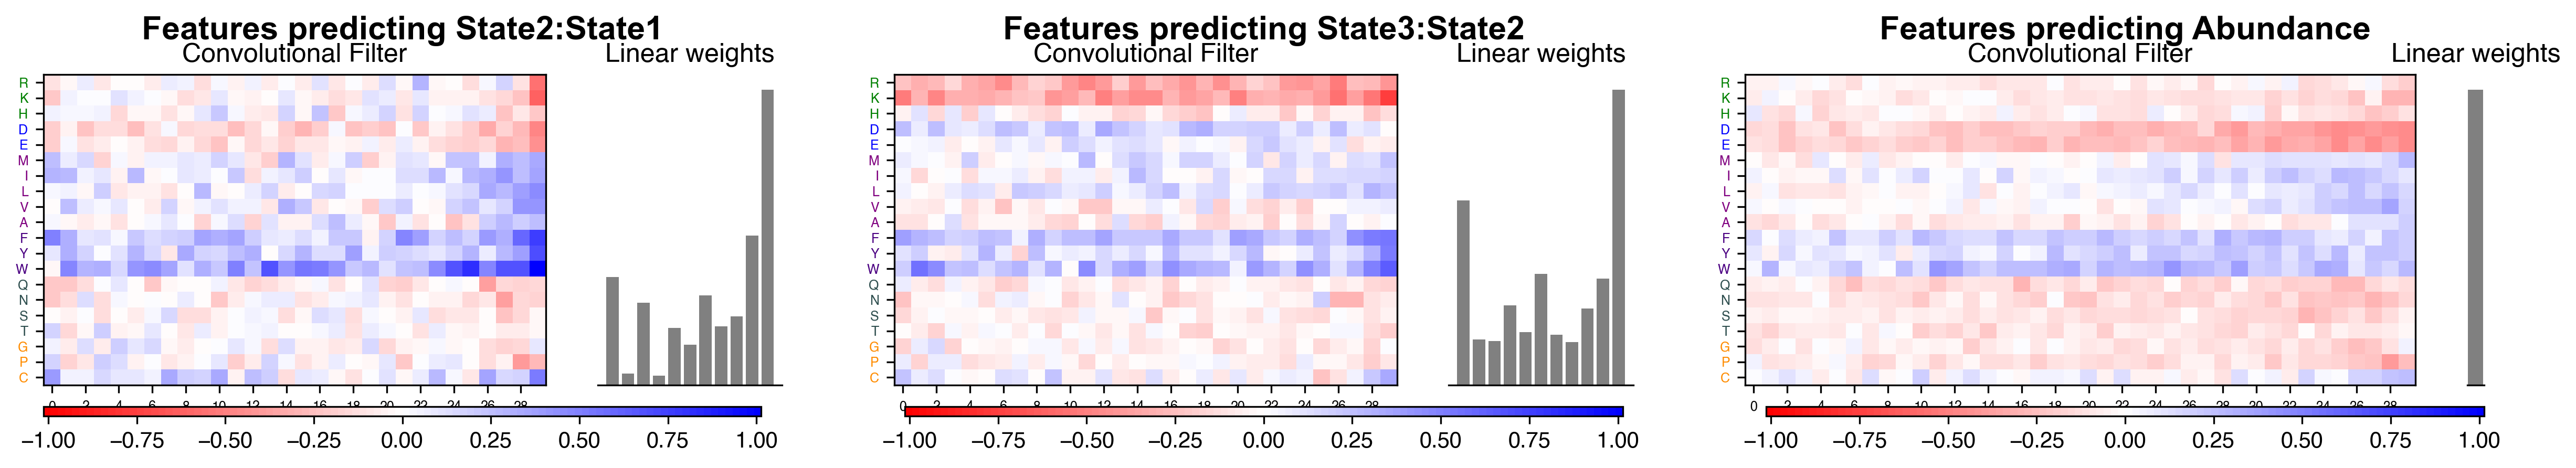

In [ ]:
num_rows = 1

# Get the max value for the heatmaps
models = [three_state_biophysical_model]
conv_weights = []

for model in models: 
    conv_weights += list(get_conv_weights(model, "conv1.weight").T.values.flatten())
    conv_weights += list(get_conv_weights(model, "conv2.weight").T.values.flatten())

lim = max([abs(w) for w in conv_weights])

# Create a figure
fig = plt.figure(figsize=(20, 3*num_rows))
title_font = {'fontsize': 15, 'fontweight': 'bold', 'fontname': 'Arial'}

# We add in "padding" rows between the rows we care about
height_ratios = [.01] + [3.3]*num_rows + [.1]

# Create a gridspec object for the title 
gs1 = gridspec.GridSpec(2 + num_rows, 3, width_ratios=[1,1,1], height_ratios=height_ratios, figure=fig)

# Title for the K1 parameters
ax1 = plt.subplot(gs1[0,0])
ax1.set_title("Features predicting State2:State1", fontdict=title_font)
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_xticklabels([])
ax1.set_yticklabels([])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.patch.set_visible(False)
ax1.axis('off')

# Title for the K2 parameters
ax2 = plt.subplot(gs1[0,1])
ax2.set_title("Features predicting State3:State2", fontdict=title_font)
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_xticklabels([])
ax2.set_yticklabels([])
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.patch.set_visible(False)
ax2.axis('off')

# Title for the abundance parameters
ax3 = plt.subplot(gs1[0,2])
ax3.set_title("Features predicting Abundance", fontdict=title_font)
ax3.set_xticks([])
ax3.set_yticks([])
ax3.set_xticklabels([])
ax3.set_yticklabels([])
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax3.spines['bottom'].set_visible(False)
ax3.patch.set_visible(False)
ax3.axis('off')

# Plot the parameters in a single row
ax1, ax2, ax3, ax4, ax5, ax6, im1, im2, im3 = make_row_plot_abund(fig, kernel_size_three, three_state_biophysical_model, 1, lim, height_ratios, num_rows, abund_k_three)

# Add titles
ax1.set_title("Convolutional Filter", fontsize=12)
ax2.set_title("Linear weights", fontsize=12)
ax3.set_title("Convolutional Filter", fontsize=12)
ax4.set_title("Linear weights", fontsize=12)
ax5.set_title("Convolutional Filter", fontsize=12)
ax6.set_title("Linear weights", fontsize=12)

# Create gridspec object for the colorbar
gs_cb = gridspec.GridSpec(2 + num_rows, 3, width_ratios=[1,1,1], height_ratios=height_ratios, figure=fig)
cax1 = plt.subplot(gs_cb[1 + num_rows,0])
cax2 = plt.subplot(gs_cb[1 + num_rows,1])
cax3 = plt.subplot(gs_cb[1 + num_rows,2])

# Add the colorbar
fig.colorbar(im1,cax=cax1, orientation='horizontal')
fig.colorbar(im2, cax=cax2, orientation='horizontal')
fig.colorbar(im3, cax=cax3, orientation='horizontal')

# plt.savefig('figures/PADI_three_state_parameters.pdf', dpi=1000, bbox_inches='tight')